In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('UTILITY.xls')


In [3]:
df.columns


Index(['Utility Charge'], dtype='str')

In [4]:
col = 'Utility Charge'
bins = [90, 110, 130, 150, 170, 190, 210]
labels = ['90-110', '110-130', '130-150', '150-170', '170-190', '190-210']

In [5]:
df['Intervalo'] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True, right=False)

In [6]:

frecuencia = df['Intervalo'].value_counts().sort_index()
porcentaje = (frecuencia / frecuencia.sum() * 100).round(2)

In [9]:
tabla = pd.DataFrame({
    'Frecuencia': frecuencia,
    'Porcentaje (%)': porcentaje
})

print(tabla)

           Frecuencia  Porcentaje (%)
Intervalo                            
90-110              6           12.50
110-130             8           16.67
130-150            12           25.00
150-170            11           22.92
170-190             7           14.58
190-210             4            8.33


In [11]:
tabla_style = tabla.style.background_gradient(cmap='Blues', subset=['Frecuencia']) \
    .format({'Porcentaje (%)': '{:.2f}%'}) \
    .set_caption('Distribución de Frecuencias - Cargos de Utilidad') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ]) \
    .set_properties(**{'border': '1px solid #ddd'})

tabla_style

,Frecuencia,Porcentaje (%)
Intervalo,,
90-110,6,12.50%
110-130,8,16.67%
130-150,12,25.00%
150-170,11,22.92%
170-190,7,14.58%
190-210,4,8.33%


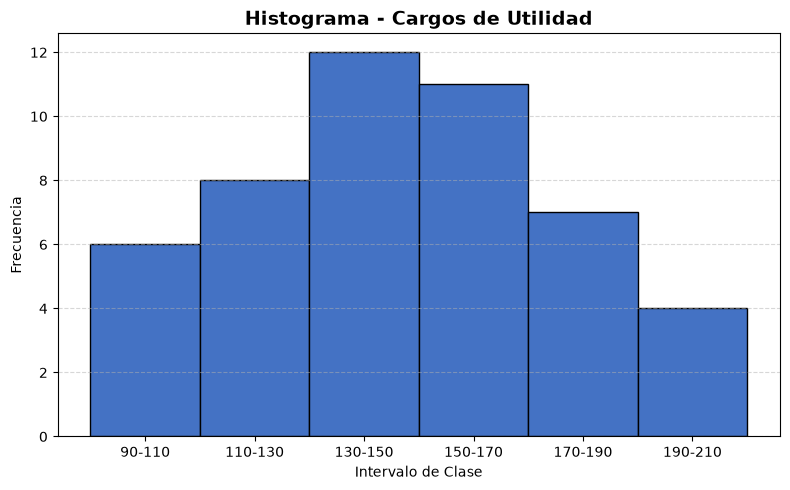

In [17]:
#te arma un histograma con barras pegadas una a la otra (como corresponde a datos continuos), usando directamente los intervalos que ya calculaste.
plt.figure(figsize=(8,5))
plt.bar(tabla.index.astype(str), tabla['Frecuencia'], width=1, color='#4472C4', edgecolor='black')

plt.title('Histograma - Cargos de Utilidad', fontsize=14, fontweight='bold')
plt.xlabel('Intervalo de Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

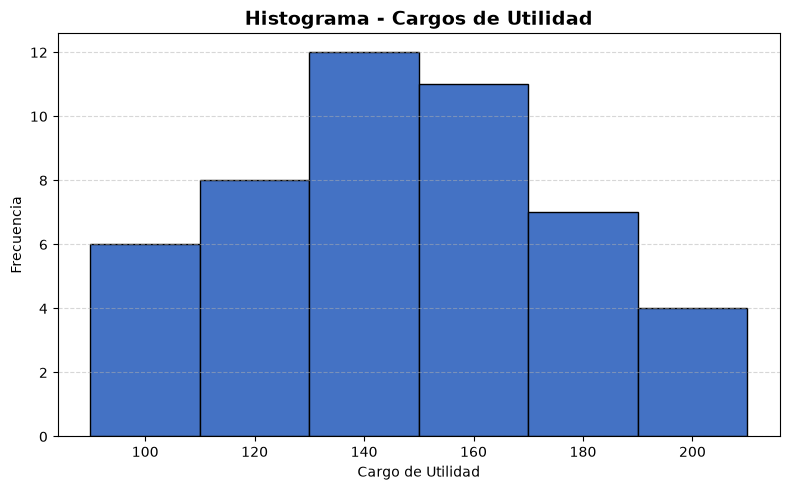

In [18]:
#Python arme el histograma solo, sin pasar por la tabla de frecuencias (es decir, directo desde los datos crudos)

plt.figure(figsize=(8,5))
plt.hist(df['Utility Charge'], bins=[90,110,130,150,170,190,210], color='#4472C4', edgecolor='black')

plt.title('Histograma - Cargos de Utilidad', fontsize=14, fontweight='bold')
plt.xlabel('Cargo de Utilidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

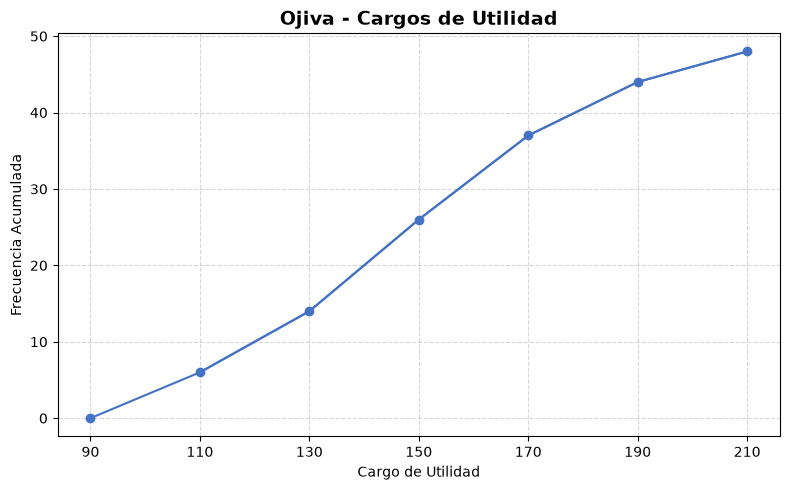

In [19]:
# Frecuencia acumulada
frecuencia_acumulada = np.cumsum(frecuencia)

# Límites superiores de cada intervalo (excluye el primer límite inferior)
limites_superiores = bins[1:]

plt.figure(figsize=(8,5))
plt.plot(limites_superiores, frecuencia_acumulada, marker='o', linestyle='-', color='#4472C4')

# Punto de inicio en (límite inferior, 0)
plt.plot([bins[0]], [0], marker='o', color='#4472C4')
plt.plot([bins[0]] + list(limites_superiores), [0] + list(frecuencia_acumulada), linestyle='-', color='#4472C4')

plt.title('Ojiva - Cargos de Utilidad', fontsize=14, fontweight='bold')
plt.xlabel('Cargo de Utilidad')
plt.ylabel('Frecuencia Acumulada')
plt.grid(linestyle='--', alpha=0.5)
plt.xticks(bins)
plt.tight_layout()
plt.show()

In [20]:
# Clase modal (intervalo con mayor frecuencia)
idx_max = np.argmax(frecuencia)
clase_modal = f"{int(bins[idx_max])}-{int(bins[idx_max+1])}"
print(f"Clase modal: {clase_modal}")

# Medidas de tendencia central sobre los datos originales
media = df['Utility Charge'].mean()
mediana = df['Utility Charge'].median()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")

Clase modal: 130-150
Media: 147.06
Mediana: 148.50
